# Opportunity Area #1: Absorption Rate Intelligence (Core)

**Marketing Question:** Where can our \\$200K–\\$300K product be sold the fastest, and how do we pace supply against demand?

**Learning Objectives:**
* Compute absorption rate and months-of-supply at county and price-band granularity.
* Visualize historical absorption trends across Lagom's target geographies.
* Identify markets where the \\$200K–\\$300K band is moving fastest today.
* Predict markets that will be moving fastest in 2-5 years with priority to locality of reference to current fastest moving markets.


In [216]:
# Import Packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX


## 1. Load and merge source data

In [217]:
# Read in data sets
df_counties =pd.read_excel("https://storage.googleapis.com/lagom-omsa/raw_data/US%20Counties.xlsx")
df_redfin =pd.read_csv("https://storage.googleapis.com/lagom-omsa/raw_data/redfin_weekly_housing_market_data_most_recent.csv")
df_realtor = pd.read_csv("https://storage.googleapis.com/lagom-omsa/raw_data/realtor_Inventory_Hotness_Metrics_County_History.csv")

# Filter Redfin data to only county level
df_redfin_county = df_redfin[df_redfin['REGION_TYPE'] == 'county'].copy()

# Split into county and state
df_redfin_county[['county', 'state']] = df_redfin_county['REGION_NAME'].str.extract(r'^(.*) County, ([A-Z]{2})$')

# Join Redfin and Realtor.com data
df_redfin_county['county_state'] = (df_redfin_county['county'].str.lower() + ', ' + df_redfin_county['state'].str.lower())
df_realtor['county_state'] = df_realtor['county_name'].str.lower()

# Convert to YYYYMM format
df_redfin_county['month_date_yyyymm'] = pd.to_datetime(df_redfin_county['PERIOD_BEGIN']).dt.strftime('%Y%m')
df_redfin_county['month_date_yyyymm'] = df_redfin_county['month_date_yyyymm'].astype(str)
df_realtor['month_date_yyyymm'] = df_realtor['month_date_yyyymm'].astype(str)

# Aggregate Redfin weekly data to county-month level
df_redfin_agg = df_redfin_county.groupby(['county_state', 'month_date_yyyymm'], as_index=False).mean(numeric_only=True)

# Merge Redfin and Realtor.com on county and month
merged = pd.merge(df_redfin_agg,df_realtor,on=['county_state', 'month_date_yyyymm'],how='inner')

# Remove duplicate county-month records if any remain.
merged = merged.drop_duplicates(subset=['county_state', 'month_date_yyyymm'])

print(merged.shape)
print(merged[['county_state', 'month_date_yyyymm']].head(25))

(159842, 62)
     county_state month_date_yyyymm
0   abbeville, sc            201708
1   abbeville, sc            201709
2   abbeville, sc            201710
3   abbeville, sc            201711
4   abbeville, sc            201712
5   abbeville, sc            201801
6   abbeville, sc            201802
7   abbeville, sc            201803
8   abbeville, sc            201804
9   abbeville, sc            201805
10  abbeville, sc            201806
11  abbeville, sc            201807
12  abbeville, sc            201808
13  abbeville, sc            201809
14  abbeville, sc            201810
15  abbeville, sc            201811
16  abbeville, sc            201812
17  abbeville, sc            201901
18  abbeville, sc            201902
19  abbeville, sc            201903
20  abbeville, sc            201904
21  abbeville, sc            201905
22  abbeville, sc            201906
23  abbeville, sc            201907
24  abbeville, sc            201908


## 2. Create absorption metrics and price bands

In [218]:
# Calculate Absorption rate
merged['absorption_rate'] = (merged['ADJUSTED_AVERAGE_HOMES_SOLD'] / merged['ACTIVE_LISTINGS']) * 100

# Calculate Months of Supply
merged['months_of_supply'] = (merged['ACTIVE_LISTINGS'] / merged['ADJUSTED_AVERAGE_HOMES_SOLD'])

# Handle divide by zero
merged = merged.replace([np.inf, -np.inf], np.nan)

# Convert YYYYMM into a date
merged['month_date'] = pd.to_datetime(merged['month_date_yyyymm'].astype(str),format='%Y%m')

# Create price bands
merged['price_band'] = pd.cut(merged['MEDIAN_SALE_PRICE'], bins=[0, 200000, 300000, 400000, float('inf')], labels=['<$200K','$200K-$300K','$300K-$400K','$400K+'], include_lowest=True)

print(merged[['county_state', 'month_date', 'MEDIAN_SALE_PRICE', 'price_band', 'absorption_rate', 'months_of_supply']].head())

    county_state month_date  MEDIAN_SALE_PRICE price_band  absorption_rate  \
0  abbeville, sc 2017-08-01      114356.181818     <$200K         4.246640   
1  abbeville, sc 2017-09-01      131094.791667     <$200K         4.976338   
2  abbeville, sc 2017-10-01      139655.196970     <$200K         3.386176   
3  abbeville, sc 2017-11-01      158698.206019     <$200K         5.839854   
4  abbeville, sc 2017-12-01      140199.242424     <$200K         4.268707   

   months_of_supply  
0         23.548027  
1         20.095098  
2         29.531840  
3         17.123717  
4         23.426296  


## 3. Filter to target price band and states

In [219]:
# Keep target price range: $200K-$300K
target_df = merged[merged['price_band'].isin(['$200K-$300K'])].copy()

# Target Southeast states
target_states = ['al', 'ar', 'fl', 'ga', 'ky','la', 'ms', 'mo', 'nc', 'sc','tn', 'va', 'wv', 'ks', 'ok', 'tx']

# Add State column
target_df['state'] = target_df['county_state'].str.split(',').str[-1].str.strip().str.lower()

# Filter to target SE states
target_df = target_df[target_df['state'].isin(target_states)].copy()

print(target_df.shape)
print(target_df[['county_state', 'state', 'price_band']].head())

(27634, 67)
     county_state state   price_band
7   abbeville, sc    sc  $200K-$300K
17  abbeville, sc    sc  $200K-$300K
30  abbeville, sc    sc  $200K-$300K
42  abbeville, sc    sc  $200K-$300K
44  abbeville, sc    sc  $200K-$300K


## 4. Aggregate to CBSA + price-band + month level

In [220]:
cbsa_monthly = target_df.groupby(
    ['cbsa_title', 'price_band', 'month_date'],
    observed=True
).agg(
    states=('state', lambda x: ', '.join(sorted(x.dropna().unique()))),
    avg_median_sale_price=('MEDIAN_SALE_PRICE', 'mean'),
    active_listings=('ACTIVE_LISTINGS', 'sum'),
    homes_sold=('ADJUSTED_AVERAGE_HOMES_SOLD', 'sum'),
    median_days_on_market=('MEDIAN_DAYS_ON_MARKET', 'mean'),
    hotness_score=('hotness_score', 'mean'),
    demand_score=('demand_score', 'mean'),
    supply_score=('supply_score', 'mean')
).reset_index()

# Calculate absorption rate for each CBSA price band month
cbsa_monthly['absorption_rate'] = (cbsa_monthly['homes_sold'] / cbsa_monthly['active_listings']) * 100

# Calculate months of supply for each CBSA price band month
cbsa_monthly['months_of_supply'] = (cbsa_monthly['active_listings'] / cbsa_monthly['homes_sold'])

cbsa_monthly = cbsa_monthly.replace([np.inf, -np.inf], np.nan)

print(cbsa_monthly.head())

    cbsa_title   price_band month_date states  avg_median_sale_price  \
0  Abilene, TX  $200K-$300K 2020-07-01     tx          205280.465278   
1  Abilene, TX  $200K-$300K 2020-08-01     tx          203691.725000   
2  Abilene, TX  $200K-$300K 2021-02-01     tx          211329.930555   
3  Abilene, TX  $200K-$300K 2021-03-01     tx          201628.388889   
4  Abilene, TX  $200K-$300K 2021-04-01     tx          211146.944444   

   active_listings  homes_sold  median_days_on_market  hotness_score  \
0       532.416667   54.319333              32.642361      51.299505   
1       513.600000   51.188733              30.858333      51.299505   
2       299.333333   40.020750              38.878472      52.568069   
3       304.733333   45.249933              27.958333      49.907178   
4       340.666667   49.999917              21.225694      64.975248   

   demand_score  supply_score  absorption_rate  months_of_supply  
0     35.581683     67.017327        10.202410          9.801605  


## 5. CBSA and price band summary

In [221]:
cbsa_price_summary = cbsa_monthly.groupby(
    ['cbsa_title', 'price_band'],
    observed=True
).agg(
    states=('states', 'first'),
    avg_absorption_rate=('absorption_rate', 'mean'),
    avg_months_of_supply=('months_of_supply', 'mean'),
    avg_sale_price=('avg_median_sale_price', 'mean'),
    avg_active_listings=('active_listings', 'mean'),
    avg_homes_sold=('homes_sold', 'mean'),
    latest_month=('month_date', 'max')
).reset_index()

print(cbsa_price_summary.head())

        cbsa_title   price_band states  avg_absorption_rate  \
0      Abilene, TX  $200K-$300K     tx             8.649833   
1          Ada, OK  $200K-$300K     ok             6.655267   
2       Albany, GA  $200K-$300K     ga            13.949051   
3    Albemarle, NC  $200K-$300K     nc             8.164680   
4  Albertville, AL  $200K-$300K     al             6.227632   

   avg_months_of_supply  avg_sale_price  avg_active_listings  avg_homes_sold  \
0             13.578880   237347.368967           534.312500       41.778140   
1             16.260906   222712.796792           127.288095        8.194868   
2             11.926820   240620.996121            17.571667        1.400108   
3             13.756056   259374.447406           238.988725       17.931760   
4             17.747310   246523.460741           354.416166       20.840634   

  latest_month  
0   2026-03-01  
1   2026-03-01  
2   2026-01-01  
3   2025-07-01  
4   2026-03-01  


## 6. Fastest moving markets today

In [222]:
latest_month = cbsa_monthly['month_date'].max()

latest_markets = cbsa_monthly[cbsa_monthly['month_date'] == latest_month].copy()

top_current_markets = latest_markets.sort_values(by='absorption_rate',ascending=False)

print("Top Current Markets in $200K-$300K Band")

print(top_current_markets[['cbsa_title','states','price_band','avg_median_sale_price','active_listings','homes_sold','absorption_rate','months_of_supply']].head(20))

Top Current Markets in $200K-$300K Band
                                  cbsa_title  states   price_band  \
14627                             Topeka, KS      ks  $200K-$300K   
12807                             Salina, KS      ks  $200K-$300K   
1096                          Bainbridge, GA      ga  $200K-$300K   
63                               Abilene, TX      tx  $200K-$300K   
12432                           Richmond, VA      va  $200K-$300K   
7471                      Jefferson City, MO      mo  $200K-$300K   
15713                            Wichita, KS      ks  $200K-$300K   
2583                    Cincinnati, OH-KY-IN      ky  $200K-$300K   
11612                          Owensboro, KY      ky  $200K-$300K   
84                                   Ada, OK      ok  $200K-$300K   
13813                       St. Louis, MO-IL      mo  $200K-$300K   
7847                      Kansas City, MO-KS  ks, mo  $200K-$300K   
9487                           Manhattan, KS      ks  $200K-$30

## 7. Rolling Window trend analysis

In [223]:
cbsa_monthly = cbsa_monthly.sort_values(by=['cbsa_title', 'price_band', 'month_date'])

cbsa_monthly['absorption_12mo_avg'] = cbsa_monthly.groupby(
    ['cbsa_title', 'price_band'],
    observed=True
)['absorption_rate'].transform(
    lambda x: x.rolling(window=12, min_periods=6).mean()
)

cbsa_monthly['absorption_24mo_avg'] = cbsa_monthly.groupby(
    ['cbsa_title', 'price_band'],
    observed=True
)['absorption_rate'].transform(
    lambda x: x.rolling(window=24, min_periods=12).mean()
)

cbsa_monthly['absorption_velocity'] = (cbsa_monthly['absorption_12mo_avg'] - cbsa_monthly['absorption_24mo_avg'])

print(cbsa_monthly[['cbsa_title','price_band','month_date','absorption_rate','absorption_12mo_avg','absorption_24mo_avg','absorption_velocity']].tail())

              cbsa_title   price_band month_date  absorption_rate  \
16064  Winston-Salem, NC  $200K-$300K 2025-10-01         4.827178   
16065  Winston-Salem, NC  $200K-$300K 2025-12-01         5.986108   
16066  Winston-Salem, NC  $200K-$300K 2026-01-01         5.311696   
16067  Winston-Salem, NC  $200K-$300K 2026-02-01         6.628788   
16068  Winston-Salem, NC  $200K-$300K 2026-03-01         6.271879   

       absorption_12mo_avg  absorption_24mo_avg  absorption_velocity  
16064             6.322986             7.178819            -0.855833  
16065             6.255954             7.080072            -0.824119  
16066             6.169859             6.991053            -0.821194  
16067             6.201879             6.972987            -0.771108  
16068             6.118967             6.902776            -0.783810  


## 8. Top markets by absorption velocity

In [224]:
latest_velocity = cbsa_monthly[cbsa_monthly['month_date'] == latest_month].copy()

top_velocity_markets = latest_velocity.sort_values(by='absorption_velocity',ascending=False)

print("Top Markets by Absorption Velocity")

print(top_velocity_markets[['cbsa_title','states','price_band','avg_median_sale_price','absorption_rate','absorption_12mo_avg','absorption_24mo_avg','absorption_velocity','months_of_supply']].head(20))

Top Markets by Absorption Velocity
                      cbsa_title states   price_band  avg_median_sale_price  \
63                   Abilene, TX     tx  $200K-$300K          248656.666667   
14679                   Troy, AL     al  $200K-$300K          231475.458333   
1096              Bainbridge, GA     ga  $200K-$300K          229644.791667   
11612              Owensboro, KY     ky  $200K-$300K          245704.166667   
348                 Amarillo, TX     tx  $200K-$300K          283783.333333   
14027             Stillwater, OK     ok  $200K-$300K          250627.777778   
15640            West Plains, MO     mo  $200K-$300K          223376.388889   
2139       Cape Girardeau, MO-IL     mo  $200K-$300K          271622.222222   
1278    Beaumont-Port Arthur, TX     tx  $200K-$300K          209416.319444   
6294                Harrison, AR     ar  $200K-$300K          239340.277778   
7471          Jefferson City, MO     mo  $200K-$300K          293441.666667   
5619             

## 9. Historical absorption rate charts

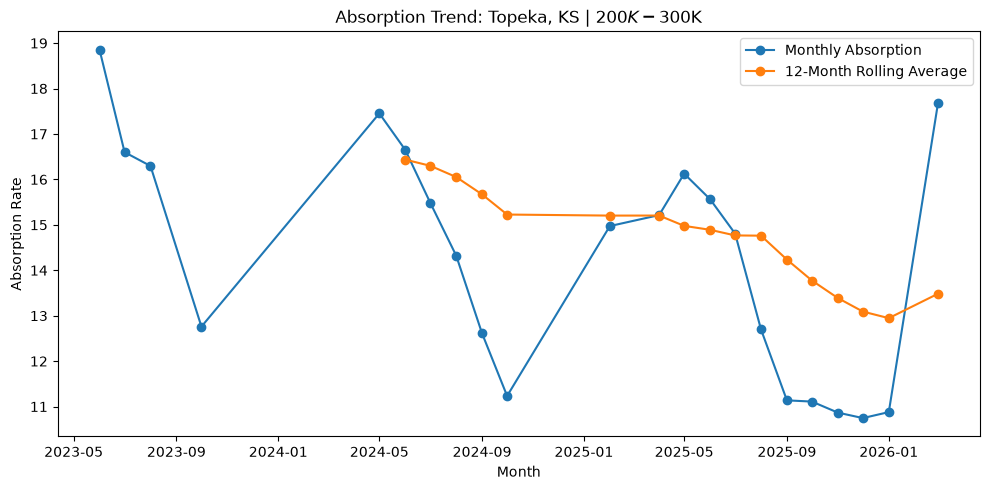

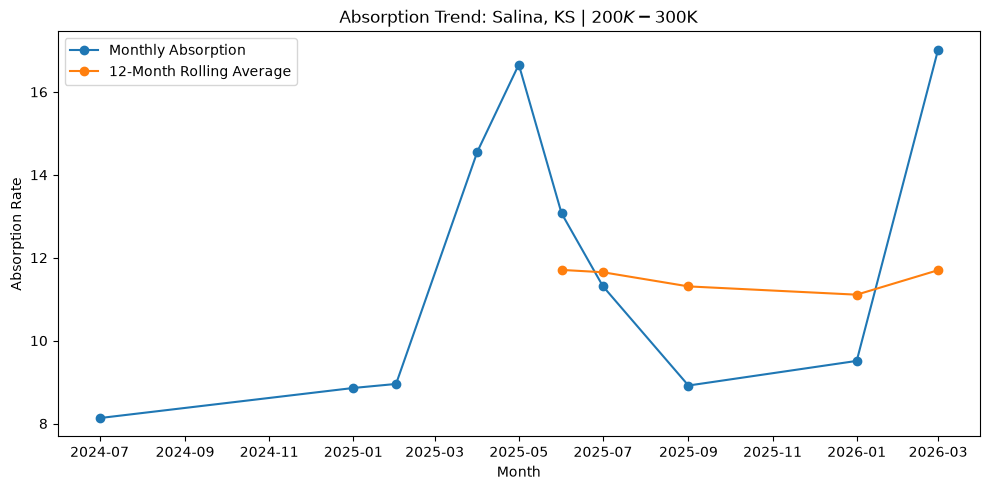

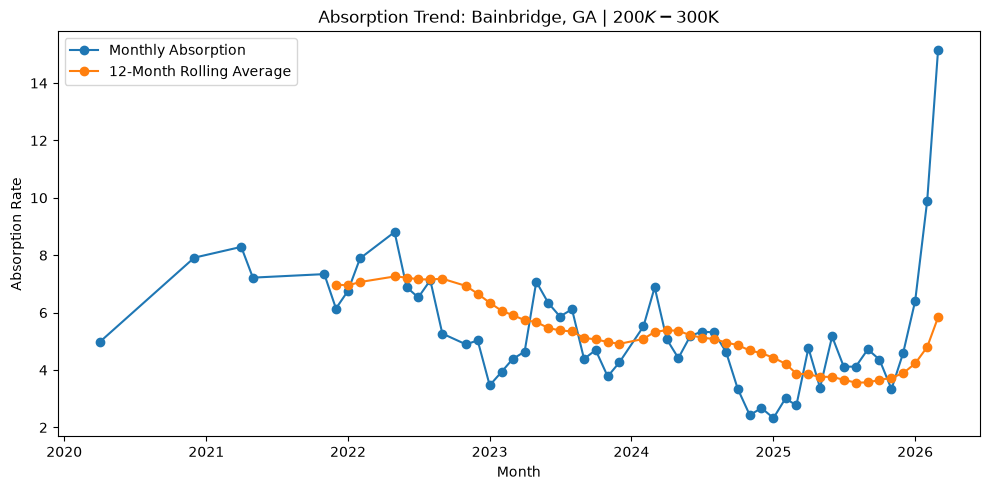

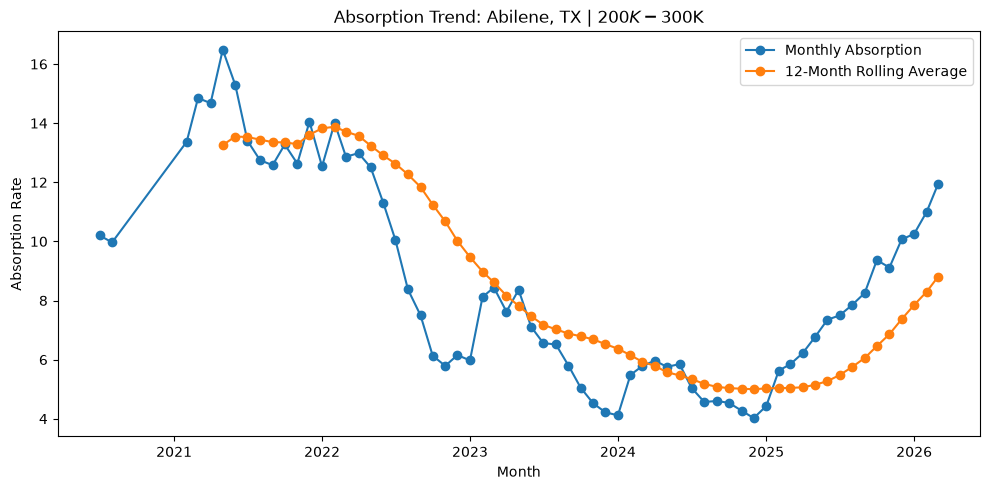

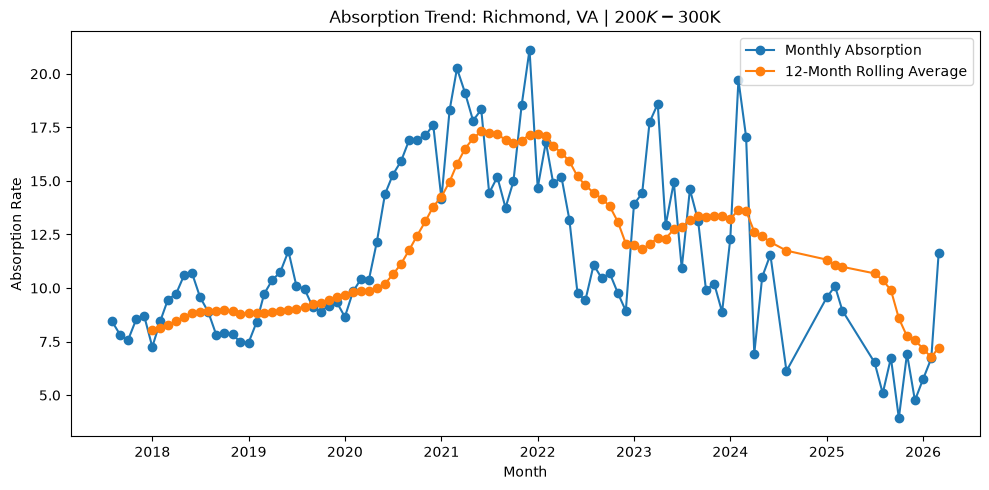

In [225]:
top_market_rows = top_current_markets.head(5)

for _, row in top_market_rows.iterrows():

    cbsa = row['cbsa_title']
    band = row['price_band']

    market_data = cbsa_monthly[(cbsa_monthly['cbsa_title'] == cbsa) & (cbsa_monthly['price_band'] == band)].copy()

    market_data = market_data.sort_values('month_date')

    plt.figure(figsize=(10, 5))

    plt.plot(market_data['month_date'],market_data['absorption_rate'],marker='o',label='Monthly Absorption')

    plt.plot(market_data['month_date'],market_data['absorption_12mo_avg'],marker='o',label='12-Month Rolling Average')

    plt.title(f'Absorption Trend: {cbsa} | {band}')
    plt.xlabel('Month')
    plt.ylabel('Absorption Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 10. Time-series absorption forecasting model


In [226]:
# We are not treating the 2-5 year horizon as an exact forecast, but instead, having our 
# model rank the markets using current absorption, rolling trend, and velocity to show forward looking time series absorption potential

FORECAST_MONTHS = 24      # Near term
TEST_MONTHS = 6           # Holdout
MIN_HISTORY_MONTHS = 18   # Min Months


def prepare_monthly_absorption_series(group):
    """Return a monthly absorption rate series for one CBSA + priceband"""
    series = (
        group
        .sort_values('month_date')
        .drop_duplicates(subset='month_date', keep='last')
        .set_index('month_date')['absorption_rate']
        .astype(float)
    )

    full_index = pd.date_range(
        series.index.min(),
        series.index.max(),
        freq='MS'
    )

    series = series.reindex(full_index)
    series = series.interpolate(method='linear').ffill().bfill()

    return series.clip(lower=0)


def regression_trend_forecast(train_series, steps):
    """Linear Regression based forecasting"""
    x = np.arange(len(train_series)).reshape(-1, 1)
    y = train_series.values

    model = LinearRegression()
    model.fit(x, y)

    future_x = np.arange(len(train_series), len(train_series) + steps).reshape(-1, 1)
    forecast = model.predict(future_x)

    return pd.Series(forecast).clip(lower=0)


def sarimax_forecast(train_series, steps, seasonal=False):
    """Fit ARIMA or SARIMA and return a forecast"""
    if seasonal and len(train_series) >= 36:
        order = (1, 1, 1)
        seasonal_order = (1, 0, 1, 12)
    else:
        order = (1, 1, 1)
        seasonal_order = (0, 0, 0, 0)

    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=steps)

    return pd.Series(forecast.values).clip(lower=0)


def evaluate_time_series_models(series):
    """Compare linear regression, ARIMA, and SARIMA on holdout period"""
    if len(series) < MIN_HISTORY_MONTHS:
        return None

    test_months = min(TEST_MONTHS, max(3, len(series) // 4))
    train = series.iloc[:-test_months]
    test = series.iloc[-test_months:]

    candidates = {}

    try:
        candidates['Regression Trend'] = regression_trend_forecast(train, test_months)
    except Exception:
        pass

    try:
        candidates['ARIMA(1,1,1)'] = sarimax_forecast(train, test_months, seasonal=False)
    except Exception:
        pass

    try:
        candidates['SARIMA(1,1,1)(1,0,1,12)'] = sarimax_forecast(train, test_months, seasonal=True)
    except Exception:
        pass

    if not candidates:
        return None

    results = []
    for name, preds in candidates.items():
        aligned_preds = np.asarray(preds)[:len(test)]
        actual = test.values[:len(aligned_preds)]

        rmse = np.sqrt(mean_squared_error(actual, aligned_preds))
        mae = mean_absolute_error(actual, aligned_preds)
        r2 = r2_score(actual, aligned_preds) if len(actual) > 1 and np.var(actual) > 0 else np.nan

        results.append({
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    results_df = pd.DataFrame(results).sort_values(by='RMSE', ascending=True)
    best_model_name = results_df.iloc[0]['Model']

    # Use the winning model on the full history and forecast
    if best_model_name == 'Regression Trend':
        future_forecast = regression_trend_forecast(series, FORECAST_MONTHS)
    elif best_model_name == 'ARIMA(1,1,1)':
        future_forecast = sarimax_forecast(series, FORECAST_MONTHS, seasonal=False)
    else:
        future_forecast = sarimax_forecast(series, FORECAST_MONTHS, seasonal=True)

    return {
        'best_model': best_model_name,
        'model_results': results_df,
        'forecast_avg_absorption': float(np.mean(future_forecast)),
        'forecast_last_absorption': float(future_forecast.iloc[-1]),
        'forecast_change_from_current': float(np.mean(future_forecast) - series.iloc[-1]),
        'history_months': int(len(series))
    }


forecast_rows = []
model_diagnostics = []

for (cbsa, band), group in cbsa_monthly.groupby(['cbsa_title', 'price_band'], observed=True):
    series = prepare_monthly_absorption_series(group)
    result = evaluate_time_series_models(series)

    if result is None:
        continue

    latest_row = (
        group[group['month_date'] == group['month_date'].max()]
        .sort_values('month_date')
        .tail(1)
        .copy()
    )

    if latest_row.empty:
        continue

    base = latest_row.iloc[0].to_dict()
    base.update({
        'time_series_model': result['best_model'],
        'forecast_avg_absorption_24mo': result['forecast_avg_absorption'],
        'forecast_last_absorption_24mo': result['forecast_last_absorption'],
        'forecast_change_from_current': result['forecast_change_from_current'],
        'history_months': result['history_months']
    })
    forecast_rows.append(base)

    diagnostics = result['model_results'].copy()
    diagnostics['cbsa_title'] = cbsa
    diagnostics['price_band'] = band
    model_diagnostics.append(diagnostics)

forecast_model_df = pd.DataFrame(forecast_rows)

if model_diagnostics:
    time_series_model_results_df = pd.concat(model_diagnostics, ignore_index=True)
else:
    time_series_model_results_df = pd.DataFrame()

print('Markets forecasted:', len(forecast_model_df))
display(forecast_model_df[[
    'cbsa_title',
    'states',
    'price_band',
    'month_date',
    'absorption_rate',
    'absorption_12mo_avg',
    'absorption_velocity',
    'time_series_model',
    'forecast_avg_absorption_24mo',
    'forecast_change_from_current',
    'history_months'
]].sort_values('forecast_avg_absorption_24mo', ascending=False).head(30))


Markets forecasted: 318


,cbsa_title,states,price_band,month_date,absorption_rate,absorption_12mo_avg,absorption_velocity,time_series_model,forecast_avg_absorption_24mo,forecast_change_from_current,history_months
45,"Charleston-North Charleston, SC",sc,$200K-$300K,2021-07-01,10.249349,8.727665,1.499790,"SARIMA(1,1,1)(1,0,1,12)",1.194816e+44,1.194816e+44,48
313,"Wilmington, NC",nc,$200K-$300K,2021-01-01,5.589557,4.910129,0.315653,"SARIMA(1,1,1)(1,0,1,12)",4.169876e+04,4.169317e+04,42
42,"Cape Coral-Fort Myers, FL",fl,$200K-$300K,2021-03-01,21.535255,10.224815,2.659533,"SARIMA(1,1,1)(1,0,1,12)",3.303292e+02,3.087940e+02,44
271,"Starkville, MS",ms,$200K-$300K,2026-02-01,42.857143,24.413562,-18.035744,"ARIMA(1,1,1)",4.416696e+01,1.309815e+00,92
66,"Crestview-Fort Walton Beach-Destin, FL",fl,$200K-$300K,2021-02-01,14.178429,10.761802,2.192252,"SARIMA(1,1,1)(1,0,1,12)",2.786319e+01,1.368476e+01,43
59,"Columbus, MS",ms,$200K-$300K,2026-02-01,32.000000,27.849430,-0.669352,Regression Trend,2.367800e+01,-8.321997e+00,70
20,"Bainbridge, GA",ga,$200K-$300K,2026-03-01,15.160500,5.835382,0.980177,"ARIMA(1,1,1)",2.266768e+01,7.507185e+00,72
281,"Tampa-St. Petersburg-Clearwater, FL",fl,$200K-$300K,2022-01-01,16.390287,17.701245,2.890669,Regression Trend,1.992462e+01,3.534333e+00,54
160,"Lakeland-Winter Haven, FL",fl,$200K-$300K,2021-12-01,17.385844,17.823430,4.142681,"ARIMA(1,1,1)",1.865800e+01,1.272156e+00,28
219,"Orlando-Kissimmee-Sanford, FL",fl,$200K-$300K,2021-06-01,18.598320,14.006391,3.209681,"ARIMA(1,1,1)",1.828049e+01,-3.178304e-01,47


## 11. Score and rank markets with time-series absorption potential


In [227]:
# Helper function for 0-1 scaling
def minmax_score(series):
    series = pd.to_numeric(series, errors='coerce')
    min_val = series.min()
    max_val = series.max()
    # Use 0.5 to avoid dividing by zero
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(0.5, index=series.index)

    return (series - min_val) / (max_val - min_val)

market_scorecard = forecast_model_df.copy()

market_scorecard['forecast_absorption_score'] = minmax_score(market_scorecard['forecast_avg_absorption_24mo'])

market_scorecard['current_absorption_score'] = minmax_score(market_scorecard['absorption_rate'])

market_scorecard['rolling_absorption_score'] = minmax_score(market_scorecard['absorption_12mo_avg'])

market_scorecard['velocity_score'] = minmax_score(market_scorecard['absorption_velocity'])

# Lower months of supply is better, so reverse the scaled value.
market_scorecard['supply_pressure_score'] = 1 - minmax_score(market_scorecard['months_of_supply'])

market_scorecard['demand_score_scaled'] = minmax_score(market_scorecard['demand_score'])

market_scorecard['hotness_score_scaled'] = minmax_score(market_scorecard['hotness_score'])

# Price fit rewards markets closest to $200K-$300K range.
market_scorecard['price_fit_score'] = (1 - ((market_scorecard['avg_median_sale_price'] - 250000).abs() / 50000)).clip(lower=0, upper=1)

# Time series forecast scorecard.
market_scorecard['market_priority_score'] = (
    0.25 * market_scorecard['forecast_absorption_score'] +
    0.20 * market_scorecard['current_absorption_score'] +
    0.15 * market_scorecard['rolling_absorption_score'] +
    0.15 * market_scorecard['velocity_score'] +
    0.10 * market_scorecard['supply_pressure_score'] +
    0.10 * market_scorecard['demand_score_scaled'] +
    0.05 * market_scorecard['price_fit_score']
)

market_scorecard = market_scorecard.sort_values(by='market_priority_score',ascending=False).reset_index(drop=True)

# Assign tier labels based on final rank percentile.
market_scorecard['rank'] = np.arange(1, len(market_scorecard) + 1)
market_scorecard['rank_percentile'] = market_scorecard['rank'] / len(market_scorecard)

market_scorecard['market_tier'] = np.select(
    [
        market_scorecard['rank_percentile'] <= 0.10,
        market_scorecard['rank_percentile'] <= 0.30
    ],
    [
        'Tier 1',
        'Tier 2'
    ],
    default='Watchlist'
)

display(market_scorecard[[
    'rank',
    'market_tier',
    'cbsa_title',
    'states',
    'price_band',
    'avg_median_sale_price',
    'absorption_rate',
    'forecast_avg_absorption_24mo',
    'forecast_change_from_current',
    'time_series_model',
    'absorption_12mo_avg',
    'absorption_24mo_avg',
    'absorption_velocity',
    'months_of_supply',
    'demand_score',
    'hotness_score',
    'market_priority_score'
]].head(30))


,rank,market_tier,cbsa_title,states,price_band,avg_median_sale_price,absorption_rate,forecast_avg_absorption_24mo,forecast_change_from_current,time_series_model,absorption_12mo_avg,absorption_24mo_avg,absorption_velocity,months_of_supply,demand_score,hotness_score,market_priority_score
0,1,Tier 1,"Charleston-North Charleston, SC",sc,$200K-$300K,297562.329861,10.249349,1.194816e+44,1.194816e+44,"SARIMA(1,1,1)(1,0,1,12)",8.727665,7.227875,1.499790,9.756717,71.844059,83.941832,0.649774
1,2,Tier 1,"Columbus, MS",ms,$200K-$300K,266000.000000,32.000000,2.367800e+01,-8.321997e+00,Regression Trend,27.849430,28.518782,-0.669352,3.125000,33.353960,50.216584,0.585263
2,3,Tier 1,"Tampa-St. Petersburg-Clearwater, FL",fl,$200K-$300K,294858.458333,16.390287,1.992462e+01,3.534333e+00,Regression Trend,17.701245,14.810576,2.890669,6.101175,91.831683,91.305693,0.511795
3,4,Tier 1,"Starkville, MS",ms,$200K-$300K,234000.000000,42.857143,4.416696e+01,1.309815e+00,"ARIMA(1,1,1)",24.413562,42.449306,-18.035744,2.333333,39.603960,39.851485,0.506390
4,5,Tier 1,"Wildwood-The Villages, FL",fl,$200K-$300K,284850.729167,24.622907,1.410441e+01,-1.051850e+01,"SARIMA(1,1,1)(1,0,1,12)",13.553836,10.372583,3.181254,4.061259,57.487624,49.969059,0.503946
5,6,Tier 1,"Lakeland-Winter Haven, FL",fl,$200K-$300K,298413.902778,17.385844,1.865800e+01,1.272156e+00,"ARIMA(1,1,1)",17.823430,13.680749,4.142681,5.751806,65.841584,65.655941,0.494964
6,7,Tier 1,"Orlando-Kissimmee-Sanford, FL",fl,$200K-$300K,296559.263889,18.598320,1.828049e+01,-3.178304e-01,"ARIMA(1,1,1)",14.006391,10.796709,3.209681,5.376830,81.683168,69.368812,0.491723
7,8,Tier 1,"Topeka, KS",ks,$200K-$300K,214250.000000,17.689295,1.151317e+01,-6.176125e+00,Regression Trend,13.484137,14.276090,-0.791953,5.653137,91.831683,91.986386,0.478873
8,9,Tier 1,"Roanoke, VA",va,$200K-$300K,296251.868056,13.117650,1.295735e+01,-1.603046e-01,"SARIMA(1,1,1)(1,0,1,12)",13.989348,11.334239,2.655109,7.623317,93.378713,78.867574,0.474298
9,10,Tier 1,"Cape Coral-Fort Myers, FL",fl,$200K-$300K,299535.311111,21.535255,3.303292e+02,3.087940e+02,"SARIMA(1,1,1)(1,0,1,12)",10.224815,7.565282,2.659533,4.643548,74.195545,62.252475,0.470217


## 12. Time-series model diagnostics


,Selected Model,Market Count
0,"ARIMA(1,1,1)",143
1,"SARIMA(1,1,1)(1,0,1,12)",124
2,Regression Trend,51


,Model,MAE,RMSE
0,"ARIMA(1,1,1)",0.951723,1.110900
2,"SARIMA(1,1,1)(1,0,1,12)",1.015965,1.175339
1,Regression Trend,2.036722,2.162343


,Regression R2
count,318.000000
mean,-412.454969
std,4247.773650
min,-60674.139772
25%,-33.447358
50%,-8.969634
75%,-2.153641
max,0.516456


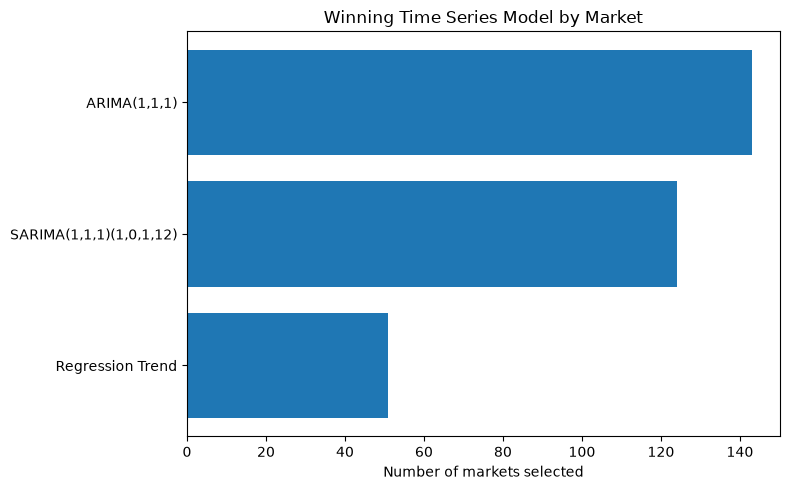

In [228]:
# Determine which time series model performed the best

if len(time_series_model_results_df) > 0:

    cleaned_time_series_model_results_df = time_series_model_results_df.copy()

    for metric in ['MAE', 'RMSE', 'R2']:
        if metric in cleaned_time_series_model_results_df.columns:
            cleaned_time_series_model_results_df = cleaned_time_series_model_results_df[
                np.isfinite(cleaned_time_series_model_results_df[metric]) | cleaned_time_series_model_results_df[metric].isna()
            ]

    # Remove extreme SARIMA result
    cleaned_time_series_model_results_df = cleaned_time_series_model_results_df[cleaned_time_series_model_results_df['RMSE'].between(0, 100)].copy()

    best_model_counts = (market_scorecard['time_series_model'].value_counts().rename_axis('Selected Model').reset_index(name='Market Count'))

    display(best_model_counts)

    avg_model_performance = (cleaned_time_series_model_results_df.groupby('Model', observed=True)[['MAE', 'RMSE']].mean().reset_index().sort_values('RMSE'))

    display(avg_model_performance)

    regression_r2_summary = (cleaned_time_series_model_results_df[cleaned_time_series_model_results_df['Model'].str.contains('Regression', case=False, na=False)]['R2'].describe().to_frame(name='Regression R2'))

    display(regression_r2_summary)

    plt.figure(figsize=(8, 5))
    plt.barh(best_model_counts['Selected Model'],best_model_counts['Market Count'])
    plt.gca().invert_yaxis()
    plt.xlabel('Number of markets selected')
    plt.title('Winning Time Series Model by Market')
    plt.tight_layout()
    plt.show()

else:
    cleaned_time_series_model_results_df = pd.DataFrame()
    print('ERROR NO RESULTS!!')


## 13. Market tier summary


In [229]:
tier_summary = market_scorecard.groupby('market_tier',as_index=False).agg(
    market_count=('cbsa_title', 'count'),
    avg_market_priority_score=('market_priority_score', 'mean'),
    avg_absorption_rate=('absorption_rate', 'mean'),
    avg_absorption_velocity=('absorption_velocity', 'mean'),
    avg_months_of_supply=('months_of_supply', 'mean'))

tier_order = ['Tier 1', 'Tier 2', 'Watchlist']
tier_summary['market_tier'] = pd.Categorical(tier_summary['market_tier'],categories=tier_order,ordered=True)

tier_summary = tier_summary.sort_values('market_tier')

display(tier_summary)


,market_tier,market_count,avg_market_priority_score,avg_absorption_rate,avg_absorption_velocity,avg_months_of_supply
0,Tier 1,31,0.453412,14.035080,0.537681,8.602607
1,Tier 2,64,0.373234,7.023647,-0.151110,15.876991
2,Watchlist,223,0.307831,4.536121,-0.589428,30.494288


## 14. Trend decomposition for top-ranked markets

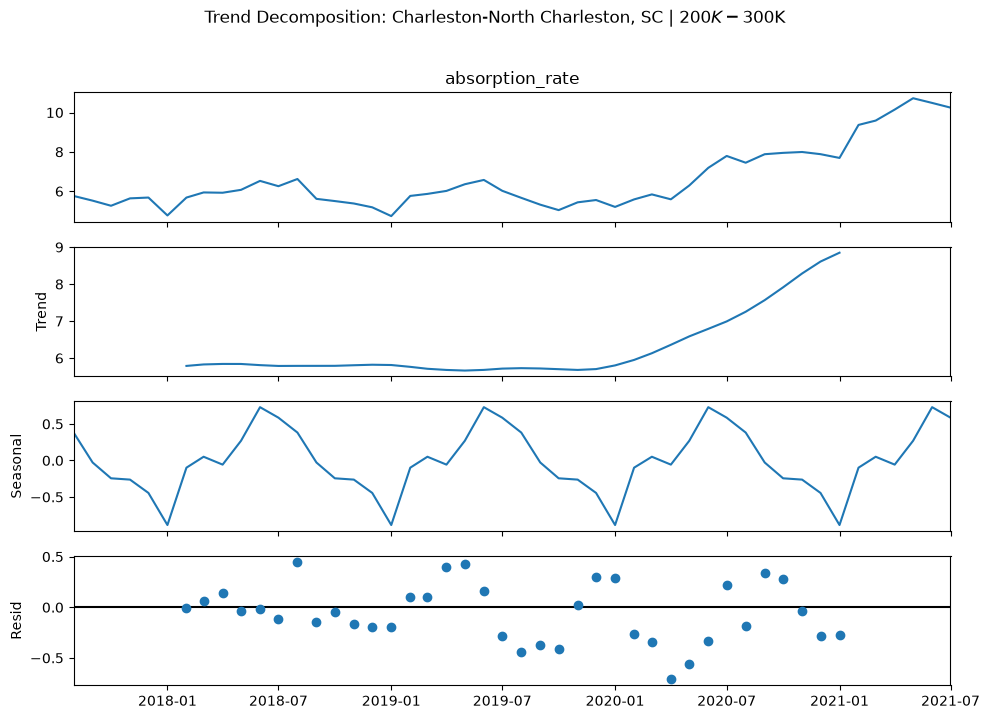

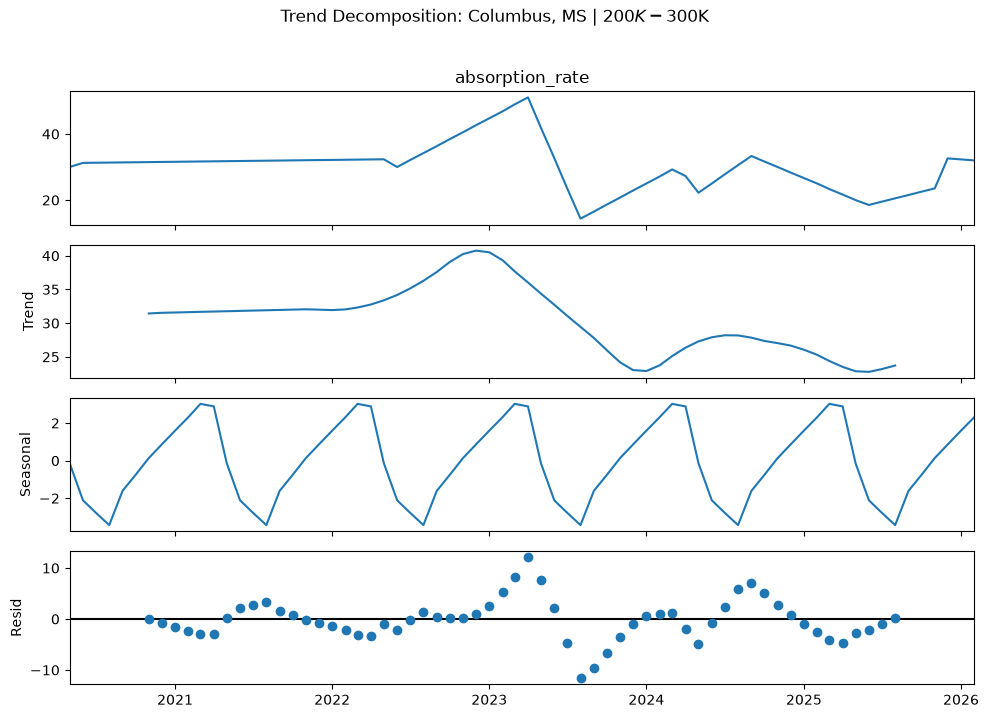

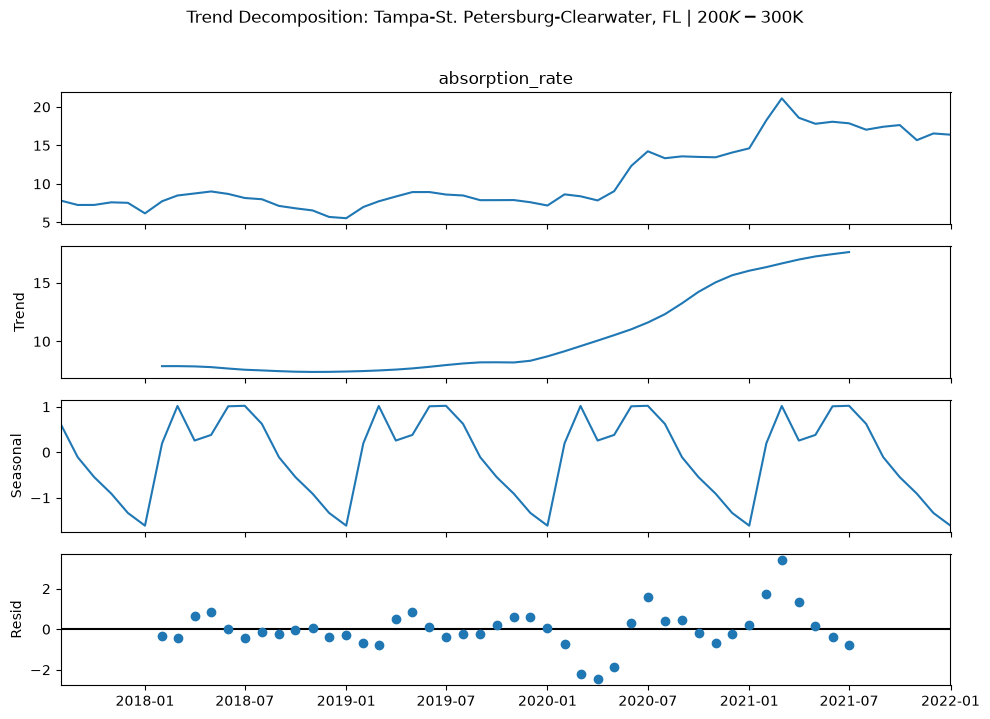

In [230]:
top_market_rows = market_scorecard.head(3)

for _, row in top_market_rows.iterrows():

    cbsa = row['cbsa_title']
    band = row['price_band']

    group = cbsa_monthly[(cbsa_monthly['cbsa_title'] == cbsa) &(cbsa_monthly['price_band'] == band)].copy()

    series = (group.sort_values('month_date').drop_duplicates(subset='month_date', keep='last').set_index('month_date')['absorption_rate'])

    full_index = pd.date_range(series.index.min(),series.index.max(),freq='MS')

    series = series.reindex(full_index).interpolate(method='linear').ffill().bfill()

    if len(series) < 24:
        continue

    decomposition = seasonal_decompose(series,model='additive',period=12)

    fig = decomposition.plot()
    fig.set_size_inches(10, 7)
    fig.suptitle(f'Trend Decomposition: {cbsa} | {band}', y=1.02)
    plt.tight_layout()
    plt.show()


## 15. Top Counties in Top CBSAs

In [231]:
top_cbsa_list = market_scorecard['cbsa_title'].head(10).unique()

county_drilldown = target_df[target_df['cbsa_title'].isin(top_cbsa_list)].copy()

county_drilldown_summary = county_drilldown.groupby(['cbsa_title', 'county_name', 'state', 'price_band'],observed=True,as_index=False).agg(
    avg_absorption_rate=('absorption_rate', 'mean'),
    avg_months_of_supply=('months_of_supply', 'mean'),
    avg_sale_price=('MEDIAN_SALE_PRICE', 'mean'),
    avg_active_listings=('ACTIVE_LISTINGS', 'mean'),
    avg_homes_sold=('ADJUSTED_AVERAGE_HOMES_SOLD', 'mean'))

county_drilldown_summary = county_drilldown_summary.sort_values(by='avg_absorption_rate',ascending=False)

display(county_drilldown_summary.head(30))


,cbsa_title,county_name,state,price_band,avg_absorption_rate,avg_months_of_supply,avg_sale_price,avg_active_listings,avg_homes_sold
12,"Starkville, MS","oktibbeha, ms",ms,$200K-$300K,46.672193,3.204358,243935.618167,3.719192,1.247864
3,"Columbus, MS","lowndes, ms",ms,$200K-$300K,28.518782,3.819774,241606.055555,4.290556,1.152585
17,"Topeka, KS","shawnee, ks",ks,$200K-$300K,14.276090,7.234028,211461.542203,327.738636,46.362387
15,"Tampa-St. Petersburg-Clearwater, FL","pasco, fl",fl,$200K-$300K,14.015062,8.434002,239394.971389,2451.667222,300.739706
4,"Lakeland-Winter Haven, FL","polk, fl",fl,$200K-$300K,13.125698,9.041376,236703.275961,2830.397436,327.562659
13,"Tampa-St. Petersburg-Clearwater, FL","hernando, fl",fl,$200K-$300K,11.629334,9.324838,243800.130594,926.663889,99.989102
14,"Tampa-St. Petersburg-Clearwater, FL","hillsborough, fl",fl,$200K-$300K,9.843055,11.277796,240829.378740,6022.206061,546.742099
8,"Orlando-Kissimmee-Sanford, FL","seminole, fl",fl,$200K-$300K,9.823731,10.705130,262081.143419,1722.074603,163.296415
16,"Tampa-St. Petersburg-Clearwater, FL","pinellas, fl",fl,$200K-$300K,9.081596,12.039103,240604.943466,5414.213258,459.707971
5,"Orlando-Kissimmee-Sanford, FL","lake, fl",fl,$200K-$300K,9.040564,12.993563,233841.057576,2101.645455,166.726114


## Model Performance Metrics Comparison

In [232]:
print('Cleaned model evaluation used for reporting:')
display(cleaned_time_series_model_results_df.groupby('Model', observed=True)[['RMSE', 'MAE']].mean().sort_values('RMSE'))

Cleaned model evaluation used for reporting:


,RMSE,MAE
Model,,
"ARIMA(1,1,1)",1.110900,0.951723
"SARIMA(1,1,1)(1,0,1,12)",1.175339,1.015965
Regression Trend,2.162343,2.036722



# Opportunity Area #2: Geographic Market Prioritization

**Marketing Question**: Which metros, counties, and ZIPs in the Southeast (and beyond) deserve our first marketing dollar?

**Learning Objectives**:
* Build a market scorecard that combines absorption, supply, demand, and demographics. 
* Identify priority metros and counties for Lagom's first wave of marketing investment.



## 16. Define Scoring Dimensions

| Dimension | Measure | Interpretation |
|---|---|---|
| Absorption velocity | Forecasted absorption, current absorption, rolling average absorption, absorption velocity | Markets where inventory is selling quickly and expected to remain strong |
| AMI fit | Median sale price closeness to Lagom's \\$200K-\\$300K target range | Proxy for affordability fit until full AMI data is added |
| Permits / inventory pressure | Months of supply, active listings, days on market | Markets with tighter inventory and faster turnover |
| Employment / migration | These dimensions were assigned neutral values in this version of the model so they do not influence market rankings. | A neutral value was assigned in this analysis so these dimensions do not influence market rankings. |
| Demand | Realtor.com demand score and hotness score | Proxy for buyer interest and market liquidity |



In [233]:
# Import Packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

geo_scorecard = market_scorecard.copy()

geo_scorecard['forecast_avg_absorption_24mo_raw'] = geo_scorecard['forecast_avg_absorption_24mo']

geo_scorecard['forecast_avg_absorption_24mo'] = pd.to_numeric(geo_scorecard['forecast_avg_absorption_24mo'], errors='coerce').replace([np.inf, -np.inf], np.nan)


geo_scorecard['forecast_avg_absorption_24mo'] = geo_scorecard['forecast_avg_absorption_24mo'].clip(lower=0, upper=100)

geo_scorecard['forecast_avg_absorption_24mo'] = geo_scorecard['forecast_avg_absorption_24mo'].fillna(geo_scorecard['absorption_rate'])

geo_scorecard['forecast_change_from_current'] = geo_scorecard['forecast_avg_absorption_24mo'] - geo_scorecard['absorption_rate']

print("Raw forecast max:", geo_scorecard['forecast_avg_absorption_24mo_raw'].max())
print("Clean forecast max:", geo_scorecard['forecast_avg_absorption_24mo'].max())
print("Clean forecast min:", geo_scorecard['forecast_avg_absorption_24mo'].min())

def safe_minmax(series, reverse=False):
    values = pd.to_numeric(series, errors='coerce')
    min_val = values.min()
    max_val = values.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        scaled = pd.Series(0.5, index=values.index)
    else:
        scaled = (values - min_val) / (max_val - min_val)

    if reverse:
        scaled = 1 - scaled

    return scaled.fillna(0.5)

# Absorption strength combines current performance, rolling trend, and forecasted future demand.
geo_scorecard['oa2_forecast_absorption_score'] = safe_minmax(geo_scorecard['forecast_avg_absorption_24mo'])
geo_scorecard['oa2_current_absorption_score'] = safe_minmax(geo_scorecard['absorption_rate'])
geo_scorecard['oa2_rolling_absorption_score'] = safe_minmax(geo_scorecard['absorption_12mo_avg'])
geo_scorecard['oa2_velocity_score'] = safe_minmax(geo_scorecard['absorption_velocity'])

geo_scorecard['absorption_velocity_dimension'] = (
    0.40 * geo_scorecard['oa2_forecast_absorption_score'] +
    0.25 * geo_scorecard['oa2_current_absorption_score'] +
    0.20 * geo_scorecard['oa2_rolling_absorption_score'] +
    0.15 * geo_scorecard['oa2_velocity_score']
)

geo_scorecard['months_supply_score'] = safe_minmax(geo_scorecard['months_of_supply'], reverse=True)
geo_scorecard['days_on_market_score'] = safe_minmax(geo_scorecard['median_days_on_market'], reverse=True)
geo_scorecard['inventory_depth_score'] = safe_minmax(geo_scorecard['active_listings'])

geo_scorecard['supply_pipeline_pressure_dimension'] = (
    0.50 * geo_scorecard['months_supply_score'] +
    0.30 * geo_scorecard['days_on_market_score'] +
    0.20 * geo_scorecard['inventory_depth_score']
)

geo_scorecard['demand_signal_score'] = safe_minmax(geo_scorecard['demand_score'])
geo_scorecard['hotness_signal_score'] = safe_minmax(geo_scorecard['hotness_score'])
geo_scorecard['sales_volume_score'] = safe_minmax(geo_scorecard['homes_sold'])

geo_scorecard['demand_tailwind_dimension'] = (
    0.45 * geo_scorecard['demand_signal_score'] +
    0.35 * geo_scorecard['hotness_signal_score'] +
    0.20 * geo_scorecard['sales_volume_score']
)

# AMI fit: Markets closest to the middle of the $200K-$300K product range are scored highest
geo_scorecard['ami_affordability_fit_dimension'] = (1 - ((geo_scorecard['avg_median_sale_price'] - 250000).abs() / 50000)).clip(lower=0, upper=1).fillna(0.5)

# Use neutral employment scoresscores so the model remains reproducible and the missing data does not distort rankings
geo_scorecard['employment_dimension'] = 0.5
geo_scorecard['migration_dimension'] = 0.5

geo_scorecard['geographic_priority_score'] = (
    0.35 * geo_scorecard['absorption_velocity_dimension'] +
    0.20 * geo_scorecard['supply_pipeline_pressure_dimension'] +
    0.15 * geo_scorecard['demand_tailwind_dimension'] +
    0.15 * geo_scorecard['ami_affordability_fit_dimension'] +
    0.075 * geo_scorecard['employment_dimension'] +
    0.075 * geo_scorecard['migration_dimension']
)

geo_scorecard = geo_scorecard.sort_values('geographic_priority_score',ascending=False).reset_index(drop=True)

geo_scorecard['geo_rank'] = np.arange(1, len(geo_scorecard) + 1)
geo_scorecard['geo_rank_percentile'] = geo_scorecard['geo_rank'] / len(geo_scorecard)

geo_scorecard['geo_market_tier'] = np.select([geo_scorecard['geo_rank_percentile'] <= 0.10,geo_scorecard['geo_rank_percentile'] <= 0.30],['Tier 1','Tier 2'],default='Watchlist')

geo_scorecard['recommended_action'] = np.select([geo_scorecard['geo_market_tier'].eq('Tier 1'),geo_scorecard['geo_market_tier'].eq('Tier 2')],
['Prioritize for first marketing efforts' ,'Monitor closely and consider targeted campaign testing'],default='Maintain on watchlist for future expansion')

display(geo_scorecard[[
    'geo_rank',
    'geo_market_tier',
    'cbsa_title',
    'states',
    'price_band',
    'avg_median_sale_price',
    'absorption_rate',
    'forecast_avg_absorption_24mo',
    'absorption_velocity',
    'months_of_supply',
    'demand_score',
    'hotness_score',
    'geographic_priority_score',
    'recommended_action'
]].head(30))


Raw forecast max: 1.1948163840288403e+44
Clean forecast max: 100.0
Clean forecast min: 0.0


,geo_rank,geo_market_tier,cbsa_title,states,price_band,avg_median_sale_price,absorption_rate,forecast_avg_absorption_24mo,absorption_velocity,months_of_supply,demand_score,hotness_score,geographic_priority_score,recommended_action
0,1,Tier 1,"Cape Coral-Fort Myers, FL",fl,$200K-$300K,299535.311111,21.535255,100.000000,2.659533,4.643548,74.195545,62.252475,0.617231,Prioritize for first marketing efforts
1,2,Tier 1,"Starkville, MS",ms,$200K-$300K,234000.000000,42.857143,44.166958,-18.035744,2.333333,39.603960,39.851485,0.594383,Prioritize for first marketing efforts
2,3,Tier 1,"Columbus, MS",ms,$200K-$300K,266000.000000,32.000000,23.678003,-0.669352,3.125000,33.353960,50.216584,0.590176,Prioritize for first marketing efforts
3,4,Tier 1,"Abilene, TX",tx,$200K-$300K,248656.666667,11.941157,12.828378,1.881676,8.374398,65.965347,68.131188,0.570039,Prioritize for first marketing efforts
4,5,Tier 1,"Charleston-North Charleston, SC",sc,$200K-$300K,297562.329861,10.249349,100.000000,1.499790,9.756717,71.844059,83.941832,0.564112,Prioritize for first marketing efforts
5,6,Tier 1,"Wichita, KS",ks,$200K-$300K,252694.907407,10.286011,10.356203,-0.398205,9.721942,71.369637,63.025990,0.562590,Prioritize for first marketing efforts
6,7,Tier 1,"Huntington-Ashland, WV-KY-OH","ky, wv",$200K-$300K,248231.930556,6.531176,7.758940,-0.518138,15.311178,94.059406,72.524752,0.553521,Prioritize for first marketing efforts
7,8,Tier 1,"Owensboro, KY",ky,$200K-$300K,245704.166667,9.875488,10.880533,0.699339,10.126082,54.888614,65.408416,0.546580,Prioritize for first marketing efforts
8,9,Tier 1,"Blacksburg-Christiansburg-Radford, VA",va,$200K-$300K,254323.611111,8.240844,8.265405,-0.835427,12.134680,81.126238,65.160891,0.537384,Prioritize for first marketing efforts
9,10,Tier 1,"Ottawa, KS",ks,$200K-$300K,245804.861111,8.661049,8.819333,-1.112894,11.545946,67.636139,59.808168,0.532852,Prioritize for first marketing efforts



## 18. Geographic market clustering

The clusters are based on absorption velocity dimension, supply / inventory pressure dimension, demand tailwind dimension, affordability fit dimension, and geographic priority score.



,cluster_id,market_count,avg_priority_score,avg_absorption_dimension,avg_supply_pressure,avg_demand_tailwind,avg_affordability_fit,avg_forecast_absorption,avg_months_of_supply,cluster_name
0,3,13,0.528756,0.494198,0.781557,0.630871,0.198964,38.974640,6.614548,High priority launch markets
1,2,121,0.449506,0.200736,0.700282,0.319180,0.775431,4.854582,22.999942,Strong absorption / selective expansion
2,1,82,0.413432,0.246538,0.737570,0.484465,0.213063,7.529096,14.723089,Emerging markets to monitor
3,0,102,0.344231,0.180021,0.652224,0.231805,0.273388,3.738141,39.281953,Lower priority watchlist markets


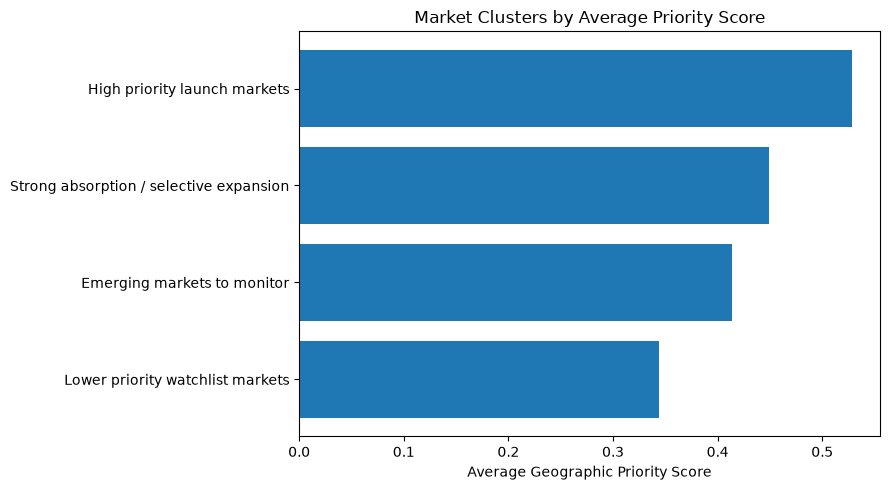

In [234]:

cluster_features = ['absorption_velocity_dimension','supply_pipeline_pressure_dimension','demand_tailwind_dimension','ami_affordability_fit_dimension','geographic_priority_score']

cluster_df = geo_scorecard[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0.5)

n_clusters = min(4, len(cluster_df))

if n_clusters >= 2:
    scaler = StandardScaler()
    cluster_matrix = scaler.fit_transform(cluster_df)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    geo_scorecard['cluster_id'] = kmeans.fit_predict(cluster_matrix)

    cluster_profile = geo_scorecard.groupby('cluster_id', as_index=False).agg(
        market_count=('cbsa_title', 'count'),
        avg_priority_score=('geographic_priority_score', 'mean'),
        avg_absorption_dimension=('absorption_velocity_dimension', 'mean'),
        avg_supply_pressure=('supply_pipeline_pressure_dimension', 'mean'),
        avg_demand_tailwind=('demand_tailwind_dimension', 'mean'),
        avg_affordability_fit=('ami_affordability_fit_dimension', 'mean'),
        avg_forecast_absorption=('forecast_avg_absorption_24mo', 'mean'),
        avg_months_of_supply=('months_of_supply', 'mean')
    )

    # Rank clusters by average priority score
    cluster_profile = cluster_profile.sort_values('avg_priority_score', ascending=False).reset_index(drop=True)
    cluster_names = ['High priority launch markets','Second priority launch markets','Emerging markets to monitor','Lower priority watchlist markets']

    cluster_profile['cluster_name'] = cluster_profile.index.map(lambda i: cluster_names[i] if i < len(cluster_names) else f'Cluster {i + 1}')

    cluster_name_map = dict(zip(cluster_profile['cluster_id'], cluster_profile['cluster_name']))
    geo_scorecard['cluster_name'] = geo_scorecard['cluster_id'].map(cluster_name_map)

    display(cluster_profile)

    plt.figure(figsize=(9, 5))
    plt.barh(cluster_profile['cluster_name'], cluster_profile['avg_priority_score'])
    plt.gca().invert_yaxis()
    plt.xlabel('Average Geographic Priority Score')
    plt.title('Market Clusters by Average Priority Score')
    plt.tight_layout()
    plt.show()
else:
    geo_scorecard['cluster_id'] = 0
    geo_scorecard['cluster_name'] = 'Single cluster'
    cluster_profile = pd.DataFrame()
    print('Not enough markets for clustering.')


## 19. Supplemental supervised classification models

In [235]:
# Import Packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

classification_features = ['absorption_velocity_dimension','supply_pipeline_pressure_dimension','demand_tailwind_dimension','ami_affordability_fit_dimension','employment_dimension','migration_dimension','forecast_avg_absorption_24mo','absorption_rate','months_of_supply','avg_median_sale_price']

classification_df = geo_scorecard[classification_features + ['geo_market_tier']].copy()
classification_df = classification_df.replace([np.inf, -np.inf], np.nan)

for col in classification_features:
    classification_df[col] = pd.to_numeric(classification_df[col], errors='coerce')
    classification_df[col] = classification_df[col].fillna(classification_df[col].median())

classification_df['is_tier1'] = classification_df['geo_market_tier'].eq('Tier 1').astype(int)

X = classification_df[classification_features]
y = classification_df['is_tier1']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

stratify_y = y if y.nunique() == 2 and y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=42,stratify=stratify_y)

classification_results = []

def record_classification_result(model_name, y_true, y_pred):
    result = {'model': model_name,'accuracy': accuracy_score(y_true, y_pred),'precision': precision_score(y_true, y_pred, zero_division=0),'recall': recall_score(y_true, y_pred, zero_division=0),'f1_score': f1_score(y_true, y_pred, zero_division=0)}
    classification_results.append(result)

    print(f"\n{model_name} Results")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

print("Classification dataset shape:", classification_df.shape)
print("Tier 1 class distribution:")
print(y.value_counts())


Classification dataset shape: (318, 12)
Tier 1 class distribution:
is_tier1
0    287
1     31
Name: count, dtype: int64


### 19A. KNN classification

In [236]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

record_classification_result('KNN Classifier', y_test, knn_pred)



KNN Classifier Results
Confusion Matrix:
[[72  0]
 [ 3  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.62      0.77         8

    accuracy                           0.96        80
   macro avg       0.98      0.81      0.87        80
weighted avg       0.96      0.96      0.96        80



### 19B. XGBoost classification


In [237]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

record_classification_result('XGBoost Classifier', y_test, xgb_pred)

xgb_feature_importance = pd.DataFrame({
    'feature': classification_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nXGBoost Feature Importance:")
display(xgb_feature_importance)



XGBoost Classifier Results
Confusion Matrix:
[[71  1]
 [ 4  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.80      0.50      0.62         8

    accuracy                           0.94        80
   macro avg       0.87      0.74      0.79        80
weighted avg       0.93      0.94      0.93        80


XGBoost Feature Importance:


,feature,importance
0,absorption_velocity_dimension,0.186072
3,ami_affordability_fit_dimension,0.181439
2,demand_tailwind_dimension,0.149311
6,forecast_avg_absorption_24mo,0.128537
8,months_of_supply,0.109676
7,absorption_rate,0.088051
9,avg_median_sale_price,0.079407
1,supply_pipeline_pressure_dimension,0.077508
4,employment_dimension,0.000000
5,migration_dimension,0.000000


### 19C. Logistic regression classification

In [238]:
logit_model = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)

logit_model.fit(X_train, y_train)
logit_pred = logit_model.predict(X_test)

record_classification_result('Logistic Regression', y_test, logit_pred)

logit_coefficients = pd.DataFrame({'feature': classification_features,'coefficient': logit_model.coef_[0]}).sort_values('coefficient', ascending=False)

print("\nLogistic Regression Coefficients:")
display(logit_coefficients)



Logistic Regression Results
Confusion Matrix:
[[68  4]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        72
           1       0.67      1.00      0.80         8

    accuracy                           0.95        80
   macro avg       0.83      0.97      0.89        80
weighted avg       0.97      0.95      0.95        80


Logistic Regression Coefficients:


,feature,coefficient
3,ami_affordability_fit_dimension,3.572579
2,demand_tailwind_dimension,2.145382
0,absorption_velocity_dimension,1.422157
1,supply_pipeline_pressure_dimension,0.767150
6,forecast_avg_absorption_24mo,0.657881
7,absorption_rate,0.585571
9,avg_median_sale_price,0.059662
4,employment_dimension,0.000000
5,migration_dimension,0.000000
8,months_of_supply,-0.027181


### 19D. Compare Supervised Models

In [239]:
classification_model_comparison = pd.DataFrame(classification_results)

if len(classification_model_comparison) > 0:
    classification_model_comparison = classification_model_comparison.sort_values(
        'f1_score',
        ascending=False
    ).reset_index(drop=True)

display(classification_model_comparison)


,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.9500,0.666667,1.000,0.800000
1,KNN Classifier,0.9625,1.000000,0.625,0.769231
2,XGBoost Classifier,0.9375,0.800000,0.500,0.615385



## 20. Executive geographic priority list

Tier definitions:

- **Tier 1:** Highest priority markets for first marketing efforts
- **Tier 2:** Strong candidates for targeted testing or near term monitoring
- **Watchlist:** Lower priority markets that may become attractive in the future


In [240]:

executive_priority_list = geo_scorecard[[
    'geo_rank',
    'geo_market_tier',
    'cluster_name',
    'cbsa_title',
    'states',
    'price_band',
    'avg_median_sale_price',
    'absorption_rate',
    'forecast_avg_absorption_24mo',
    'forecast_change_from_current',
    'months_of_supply',
    'demand_score',
    'hotness_score',
    'absorption_velocity_dimension',
    'supply_pipeline_pressure_dimension',
    'demand_tailwind_dimension',
    'ami_affordability_fit_dimension',
    'geographic_priority_score',
    'recommended_action'
]].copy()

# Round
round_cols = executive_priority_list.select_dtypes(include='number').columns
executive_priority_list[round_cols] = executive_priority_list[round_cols].round(3)

display(executive_priority_list.head(25))


,geo_rank,geo_market_tier,cluster_name,cbsa_title,states,price_band,avg_median_sale_price,absorption_rate,forecast_avg_absorption_24mo,forecast_change_from_current,months_of_supply,demand_score,hotness_score,absorption_velocity_dimension,supply_pipeline_pressure_dimension,demand_tailwind_dimension,ami_affordability_fit_dimension,geographic_priority_score,recommended_action
0,1,Tier 1,High priority launch markets,"Cape Coral-Fort Myers, FL",fl,$200K-$300K,299535.311,21.535,100.000,78.465,4.644,74.196,62.252,0.735,0.831,0.782,0.009,0.617,Prioritize for first marketing efforts
1,2,Tier 1,High priority launch markets,"Starkville, MS",ms,$200K-$300K,234000.000,42.857,44.167,1.310,2.333,39.604,39.851,0.601,0.785,0.332,0.680,0.594,Prioritize for first marketing efforts
2,3,Tier 1,High priority launch markets,"Columbus, MS",ms,$200K-$300K,266000.000,32.000,23.678,-8.322,3.125,33.354,50.217,0.599,0.761,0.343,0.680,0.590,Prioritize for first marketing efforts
3,4,Tier 1,Strong absorption / selective expansion,"Abilene, TX",tx,$200K-$300K,248656.667,11.941,12.828,0.887,8.374,65.965,68.131,0.315,0.761,0.578,0.973,0.570,Prioritize for first marketing efforts
4,5,Tier 1,High priority launch markets,"Charleston-North Charleston, SC",sc,$200K-$300K,297562.330,10.249,100.000,89.751,9.757,71.844,83.942,0.650,0.759,0.683,0.049,0.564,Prioritize for first marketing efforts
5,6,Tier 1,Strong absorption / selective expansion,"Wichita, KS",ks,$200K-$300K,252694.907,10.286,10.356,0.070,9.722,71.370,63.026,0.278,0.775,0.622,0.946,0.563,Prioritize for first marketing efforts
6,7,Tier 1,Strong absorption / selective expansion,"Huntington-Ashland, WV-KY-OH","ky, wv",$200K-$300K,248231.931,6.531,7.759,1.228,15.311,94.059,72.525,0.235,0.719,0.718,0.965,0.554,Prioritize for first marketing efforts
7,8,Tier 1,Strong absorption / selective expansion,"Owensboro, KY",ky,$200K-$300K,245704.167,9.875,10.881,1.005,10.126,54.889,65.408,0.304,0.758,0.510,0.914,0.547,Prioritize for first marketing efforts
8,9,Tier 1,Strong absorption / selective expansion,"Blacksburg-Christiansburg-Radford, VA",va,$200K-$300K,254323.611,8.241,8.265,0.025,12.135,81.126,65.161,0.246,0.725,0.628,0.914,0.537,Prioritize for first marketing efforts
9,10,Tier 1,Strong absorption / selective expansion,"Ottawa, KS",ks,$200K-$300K,245804.861,8.661,8.819,0.158,11.546,67.636,59.808,0.259,0.742,0.543,0.916,0.533,Prioritize for first marketing efforts



## 21. Summary by Tier

In [241]:

geo_tier_summary = geo_scorecard.groupby('geo_market_tier', as_index=False).agg(
    market_count=('cbsa_title', 'count'),
    avg_priority_score=('geographic_priority_score', 'mean'),
    avg_forecast_absorption=('forecast_avg_absorption_24mo', 'mean'),
    avg_current_absorption=('absorption_rate', 'mean'),
    avg_months_of_supply=('months_of_supply', 'mean'),
    avg_sale_price=('avg_median_sale_price', 'mean'),
    avg_demand_tailwind=('demand_tailwind_dimension', 'mean')
)

geo_tier_summary['geo_market_tier'] = pd.Categorical(geo_tier_summary['geo_market_tier'],categories=['Tier 1', 'Tier 2', 'Watchlist'],ordered=True)

geo_tier_summary = geo_tier_summary.sort_values('geo_market_tier')

numeric_cols = geo_tier_summary.select_dtypes(include='number').columns
geo_tier_summary[numeric_cols] = geo_tier_summary[numeric_cols].round(3)

display(geo_tier_summary)


,geo_market_tier,market_count,avg_priority_score,avg_forecast_absorption,avg_current_absorption,avg_months_of_supply,avg_sale_price,avg_demand_tailwind
0,Tier 1,31,0.526,20.083,11.851,11.957,262356.502,0.564
1,Tier 2,64,0.462,6.654,6.907,17.541,260902.902,0.445
2,Watchlist,223,0.378,4.683,4.873,29.551,261758.735,0.288



## 22. Tier 1 County Level Analysis

In [242]:

tier1_cbsa = geo_scorecard.loc[geo_scorecard['geo_market_tier'].eq('Tier 1'),'cbsa_title'].dropna().unique()

geo_county_drilldown = target_df[target_df['cbsa_title'].isin(tier1_cbsa)].copy()

geo_county_priority = geo_county_drilldown.groupby(
    ['cbsa_title', 'county_name', 'state', 'price_band'],
    observed=True,
    as_index=False
).agg(
    avg_absorption_rate=('absorption_rate', 'mean'),
    avg_months_of_supply=('months_of_supply', 'mean'),
    avg_sale_price=('MEDIAN_SALE_PRICE', 'mean'),
    avg_active_listings=('ACTIVE_LISTINGS', 'mean'),
    avg_homes_sold=('ADJUSTED_AVERAGE_HOMES_SOLD', 'mean'),
    avg_days_on_market=('MEDIAN_DAYS_ON_MARKET', 'mean'),
    avg_demand_score=('demand_score', 'mean'),
    avg_hotness_score=('hotness_score', 'mean')
)

geo_county_priority['county_absorption_score'] = safe_minmax(geo_county_priority['avg_absorption_rate'])
geo_county_priority['county_supply_score'] = safe_minmax(geo_county_priority['avg_months_of_supply'], reverse=True)
geo_county_priority['county_price_fit_score'] = (
    1 - ((geo_county_priority['avg_sale_price'] - 250000).abs() / 50000)
).clip(lower=0, upper=1).fillna(0.5)
geo_county_priority['county_demand_score_scaled'] = safe_minmax(geo_county_priority['avg_demand_score'])

geo_county_priority['county_priority_score'] = (
    0.40 * geo_county_priority['county_absorption_score'] +
    0.25 * geo_county_priority['county_supply_score'] +
    0.20 * geo_county_priority['county_price_fit_score'] +
    0.15 * geo_county_priority['county_demand_score_scaled']
)

geo_county_priority = geo_county_priority.sort_values('county_priority_score',ascending=False).reset_index(drop=True)

geo_county_priority['county_rank'] = np.arange(1, len(geo_county_priority) + 1)

county_display = geo_county_priority[[
    'county_rank',
    'cbsa_title',
    'county_name',
    'state',
    'price_band',
    'avg_sale_price',
    'avg_absorption_rate',
    'avg_months_of_supply',
    'avg_active_listings',
    'avg_homes_sold',
    'avg_days_on_market',
    'county_priority_score'
]].copy()

county_display[county_display.select_dtypes(include='number').columns] = county_display.select_dtypes(include='number').round(3)

display(county_display.head(40))


,county_rank,cbsa_title,county_name,state,price_band,avg_sale_price,avg_absorption_rate,avg_months_of_supply,avg_active_listings,avg_homes_sold,avg_days_on_market,county_priority_score
0,1,"Starkville, MS","oktibbeha, ms",ms,$200K-$300K,243935.618,46.672,3.204,3.719,1.248,151.239,0.863
1,2,"Columbus, MS","lowndes, ms",ms,$200K-$300K,241606.056,28.519,3.820,4.291,1.153,74.830,0.671
2,3,"St. Louis, MO-IL","st. charles, mo",mo,$200K-$300K,247166.025,14.546,8.042,1101.305,141.446,27.336,0.636
3,4,"Tampa-St. Petersburg-Clearwater, FL","hernando, fl",fl,$200K-$300K,243800.131,11.629,9.325,926.664,99.989,38.178,0.625
4,5,"St. Louis, MO-IL","st. louis, mo",mo,$200K-$300K,242837.192,13.747,7.648,2179.096,288.984,18.639,0.611
5,6,"Tampa-St. Petersburg-Clearwater, FL","pasco, fl",fl,$200K-$300K,239394.971,14.015,8.434,2451.667,300.740,22.533,0.608
6,7,"St. Louis, MO-IL","warren, mo",mo,$200K-$300K,251072.443,14.641,8.102,98.960,13.013,27.126,0.602
7,8,"Kansas City, MO-KS","clay, mo",mo,$200K-$300K,244723.469,13.291,8.094,750.598,96.540,20.349,0.601
8,9,"St. Louis, MO-IL","jefferson, mo",mo,$200K-$300K,253375.622,13.258,7.768,462.176,60.979,23.063,0.596
9,10,"Lynchburg, VA","amherst, va",va,$200K-$300K,244931.772,11.021,9.549,63.668,6.723,38.764,0.584



## 23. Weight Sensitivity Check

The market priority score depends heavily on assigned weights, so this section tests whether top markets remain strong under an alternate weighting scenario.

In this part, we give slightly more weight to affordability and supply pressure, and slightly less weight to forecasted absorption.


In [243]:

geo_scorecard['alternate_priority_score'] = (
    0.25 * geo_scorecard['absorption_velocity_dimension'] +
    0.25 * geo_scorecard['supply_pipeline_pressure_dimension'] +
    0.15 * geo_scorecard['demand_tailwind_dimension'] +
    0.20 * geo_scorecard['ami_affordability_fit_dimension'] +
    0.075 * geo_scorecard['employment_dimension'] +
    0.075 * geo_scorecard['migration_dimension']
)

geo_scorecard['alternate_rank'] = geo_scorecard['alternate_priority_score'].rank(method='first',ascending=False).astype(int)

sensitivity_check = geo_scorecard[[
    'cbsa_title',
    'states',
    'price_band',
    'geo_rank',
    'alternate_rank',
    'geo_market_tier',
    'geographic_priority_score',
    'alternate_priority_score'
]].copy()

sensitivity_check['rank_change'] = sensitivity_check['alternate_rank'] - sensitivity_check['geo_rank']

sensitivity_check = sensitivity_check.sort_values('geo_rank')

sensitivity_check[sensitivity_check.select_dtypes(include='number').columns] = sensitivity_check.select_dtypes(include='number').round(3)

display(sensitivity_check.head(25))

print('Median absolute rank change among top 25 markets:')
print(sensitivity_check.head(25)['rank_change'].abs().median())

,cbsa_title,states,price_band,geo_rank,alternate_rank,geo_market_tier,geographic_priority_score,alternate_priority_score,rank_change
0,"Cape Coral-Fort Myers, FL",fl,$200K-$300K,1,10,Tier 1,0.617,0.586,9
1,"Starkville, MS",ms,$200K-$300K,2,4,Tier 1,0.594,0.608,2
2,"Columbus, MS",ms,$200K-$300K,3,5,Tier 1,0.590,0.602,2
3,"Abilene, TX",tx,$200K-$300K,4,1,Tier 1,0.570,0.625,-3
4,"Charleston-North Charleston, SC",sc,$200K-$300K,5,23,Tier 1,0.564,0.539,18
5,"Wichita, KS",ks,$200K-$300K,6,2,Tier 1,0.563,0.621,-4
6,"Huntington-Ashland, WV-KY-OH","ky, wv",$200K-$300K,7,3,Tier 1,0.554,0.614,-4
7,"Owensboro, KY",ky,$200K-$300K,8,6,Tier 1,0.547,0.600,-2
8,"Blacksburg-Christiansburg-Radford, VA",va,$200K-$300K,9,8,Tier 1,0.537,0.595,-1
9,"Ottawa, KS",ks,$200K-$300K,10,9,Tier 1,0.533,0.590,-1


Median absolute rank change among top 25 markets:
4.0



## 24. Streamlit Dashboard Data Export



In [244]:
# Creates the dashboard_data folder that Streamlit reads from.

from pathlib import Path

dashboard_dir = Path("dashboard_data")
dashboard_dir.mkdir(exist_ok=True)

def export_if_exists(df_name, file_name):
    if df_name in globals():
        df = globals()[df_name].copy()
        df.to_csv(dashboard_dir / file_name, index=False)
        print(f"Exported {file_name}: {df.shape[0]} rows, {df.shape[1]} columns")
    else:
        print(f"Skipped {file_name}: {df_name} not found")

export_if_exists("geo_scorecard", "geo_scorecard.csv")
export_if_exists("market_scorecard", "market_scorecard.csv")
export_if_exists("cbsa_monthly", "cbsa_monthly.csv")
export_if_exists("top_current_markets", "top_current_markets.csv")
export_if_exists("latest_velocity", "top_absorption_velocity.csv")
export_if_exists("tier_summary", "tier_summary.csv")
export_if_exists("cluster_profile", "cluster_profile.csv")
export_if_exists("classification_model_comparison", "classification_model_comparison.csv")
export_if_exists("xgb_feature_importance", "xgb_feature_importance.csv")
export_if_exists("logit_coefficients", "logit_coefficients.csv")
export_if_exists("tier1_drilldown", "tier1_drilldown.csv")
export_if_exists("top_geo_markets", "top_geo_markets.csv")

print("\nDashboard data export complete.")

Exported geo_scorecard.csv: 318 rows, 59 columns
Exported market_scorecard.csv: 318 rows, 33 columns
Exported cbsa_monthly.csv: 16069 rows, 16 columns
Exported top_current_markets.csv: 201 rows, 13 columns
Exported top_absorption_velocity.csv: 201 rows, 16 columns
Exported tier_summary.csv: 3 rows, 6 columns
Exported cluster_profile.csv: 4 rows, 10 columns
Exported classification_model_comparison.csv: 3 rows, 5 columns
Exported xgb_feature_importance.csv: 10 rows, 2 columns
Exported logit_coefficients.csv: 10 rows, 2 columns
Skipped tier1_drilldown.csv: tier1_drilldown not found
Skipped top_geo_markets.csv: top_geo_markets not found

Dashboard data export complete.
